# Dementia Progression: Optimized Hybrid RPDPM

**Strategy:** RPDPM-based feature engineering + aggressive XGBoost tuning + perfect class balance

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import curve_fit
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.utils import resample
from sklearn.utils.class_weight import compute_sample_weight
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

## 2. Load Data

In [2]:
df = pd.read_csv('oasis_longitudinal.csv')
print(f'Dataset: {df.shape}')

def get_stage(row):
    if row['CDR'] == 0: return 0
    elif row['CDR'] == 0.5: return 1
    else: return 2

stage_labels = {0: 'No Dementia', 1: 'Very Mild', 2: 'Dementia'}
df = df.dropna(subset=['CDR'])
df['Stage'] = df.apply(get_stage, axis=1)

print('\nOriginal distribution:')
print(df['Stage'].value_counts().sort_index())

Dataset: (373, 15)

Original distribution:
Stage
0    206
1    123
2     44
Name: count, dtype: int64


## 3. Perfect Balancing

In [3]:
# Balance to Very Mild count (largest minority class)
df_majority = df[df['Stage'] == 1]
target_count = len(df_majority)

df_0 = resample(df[df['Stage'] == 0], replace=True, n_samples=target_count, random_state=42)
df_2 = resample(df[df['Stage'] == 2], replace=True, n_samples=target_count, random_state=42)
df_balanced = pd.concat([df_majority, df_0, df_2])

print(f'Balanced dataset: {len(df_balanced)} samples')
print(df_balanced['Stage'].value_counts().sort_index())

df_balanced = df_balanced.copy()
df_balanced['M/F'] = LabelEncoder().fit_transform(df_balanced['M/F'].astype(str))
features = ['Visit', 'Age', 'EDUC', 'SES', 'MMSE', 'eTIV', 'nWBV', 'ASF', 'M/F']
for col in features:
    df_balanced[col] = df_balanced[col].fillna(df_balanced[col].median())

X = df_balanced[features]
y = df_balanced['Stage']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f'\nTrain: {len(X_train)} | Test: {len(X_test)}')

Balanced dataset: 369 samples
Stage
0    123
1    123
2    123
Name: count, dtype: int64

Train: 295 | Test: 74


## 4. Hybrid RPDPM with Maximum Feature Engineering

Combines RPDPM curve fitting with XGBoost for optimal accuracy

In [4]:
def logistic(t, A, k, t0, C):
    return A / (1 + np.exp(-k * (t - t0))) + C

class HybridRPDPM:
    def __init__(self):
        self.biomarkers = ['MMSE', 'nWBV']
        self.all_features = ['Visit', 'Age', 'EDUC', 'SES', 'MMSE', 'eTIV', 'nWBV', 'ASF', 'M/F']
        self.params = {}
        self.scaler = StandardScaler()
        self.classifier = XGBClassifier(
            n_estimators=500,
            learning_rate=0.02,
            max_depth=8,
            subsample=0.75,
            colsample_bytree=0.65,
            min_child_weight=1,
            gamma=0.15,
            reg_alpha=0.15,
            reg_lambda=1.5,
            random_state=42,
            eval_metric='mlogloss',
            tree_method='hist'
        )
        
    def fit(self, X, y):
        # Fit RPDPM curves
        for marker in self.biomarkers:
            age_vals = X['Age'].values
            marker_vals = X[marker].values
            
            try:
                popt, _ = curve_fit(
                    logistic, age_vals, marker_vals,
                    p0=[marker_vals.max() - marker_vals.min(), -0.15, age_vals.mean(), marker_vals.min()],
                    maxfev=20000, method='trf'
                )
                self.params[marker] = popt
            except:
                self.params[marker] = [marker_vals.max() - marker_vals.min(), -0.1, age_vals.mean(), marker_vals.mean()]
        
        # Engineer features
        X_enhanced = self._engineer_features(X)
        X_scaled = self.scaler.fit_transform(X_enhanced)
        
        # Train with sample weights
        weights = compute_sample_weight(class_weight='balanced', y=y)
        self.classifier.fit(X_scaled, y, sample_weight=weights)
        
        return self
    
    def _engineer_features(self, X):
        X_new = X.copy()
        
        for marker in self.biomarkers:
            A, k, t0, C = self.params[marker]
            expected = logistic(X['Age'].values, A, k, t0, C)
            
            # RPDPM-based features
            X_new[f'{marker}_expected'] = expected
            X_new[f'{marker}_deviation'] = X[marker].values - expected
            X_new[f'{marker}_rel_deviation'] = (X[marker].values - expected) / (np.abs(expected) + 1e-5)
            X_new[f'{marker}_squared_dev'] = (X[marker].values - expected) ** 2
        
        # Interaction features
        X_new['MMSE_nWBV_product'] = X['MMSE'] * X['nWBV']
        X_new['MMSE_nWBV_ratio'] = X['MMSE'] / (X['nWBV'] + 1e-5)
        X_new['MMSE_Age_ratio'] = X['MMSE'] / (X['Age'] + 1)
        X_new['nWBV_Age_product'] = X['nWBV'] * X['Age']
        X_new['MMSE_Visit_product'] = X['MMSE'] * X['Visit']
        X_new['nWBV_Visit_product'] = X['nWBV'] * X['Visit']
        
        # Polynomial features for key biomarkers
        X_new['MMSE_squared'] = X['MMSE'] ** 2
        X_new['nWBV_squared'] = X['nWBV'] ** 2
        X_new['Age_squared'] = X['Age'] ** 2
        
        return X_new
    
    def predict(self, X):
        X_enhanced = self._engineer_features(X)
        X_scaled = self.scaler.transform(X_enhanced)
        return self.classifier.predict(X_scaled)
    
    def predict_proba(self, X):
        X_enhanced = self._engineer_features(X)
        X_scaled = self.scaler.transform(X_enhanced)
        return self.classifier.predict_proba(X_scaled)

print('Hybrid RPDPM implemented with 22 engineered features')

Hybrid RPDPM implemented with 22 engineered features


## 5. Train All Models

In [5]:
models = {
    'Hybrid RPDPM (Primary)': HybridRPDPM(),
    'XGBoost': XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=6,
                              subsample=0.8, colsample_bytree=0.8, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced'),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=150, learning_rate=0.1, random_state=42),
    'SVM': SVC(probability=True, random_state=42, class_weight='balanced'),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
}

results = {}

print('Training all models...\n')
for name, model in models.items():
    print(f'Training {name}...')
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)
    acc = accuracy_score(y_test, y_pred)
    
    try:
        from sklearn.preprocessing import label_binarize
        y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
        auc = roc_auc_score(y_test_bin, y_prob, average='macro', multi_class='ovr')
    except:
        auc = 0
    
    results[name] = {'model': model, 'accuracy': acc, 'auc': auc, 'y_pred': y_pred, 'y_prob': y_prob}
    print(f'  ✓ Accuracy: {acc:.4f} | AUC: {auc:.4f}\n')

print('All models trained!')

Training all models...

Training Hybrid RPDPM (Primary)...
  ✓ Accuracy: 0.8108 | AUC: 0.9464

Training XGBoost...
  ✓ Accuracy: 0.8243 | AUC: 0.9625

Training Random Forest...
  ✓ Accuracy: 0.8243 | AUC: 0.9694

Training Gradient Boosting...
  ✓ Accuracy: 0.8243 | AUC: 0.9450

Training SVM...
  ✓ Accuracy: 0.2703 | AUC: 0.5634

Training Logistic Regression...
  ✓ Accuracy: 0.6216 | AUC: 0.8220

All models trained!


## 6. Model Comparison

In [6]:
comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy': [results[m]['accuracy'] for m in results.keys()],
    'AUC': [results[m]['auc'] for m in results.keys()]
})

comparison_df = comparison_df.sort_values('Accuracy', ascending=False)
print('\n' + '='*70)
print('MODEL COMPARISON RESULTS')
print('='*70)
print(comparison_df.to_string(index=False))
print('='*70)
print(f'\n🏆 Best Model: {comparison_df.iloc[0]["Model"]} '
      f'with {comparison_df.iloc[0]["Accuracy"]:.2%} accuracy')
print(f'   Improvement over 2nd place: '
      f'{(comparison_df.iloc[0]["Accuracy"] - comparison_df.iloc[1]["Accuracy"])*100:+.2f}%')


MODEL COMPARISON RESULTS
                 Model  Accuracy      AUC
               XGBoost  0.824324 0.962483
         Random Forest  0.824324 0.969433
     Gradient Boosting  0.824324 0.944960
Hybrid RPDPM (Primary)  0.810811 0.946355
   Logistic Regression  0.621622 0.821995
                   SVM  0.270270 0.563362

🏆 Best Model: XGBoost with 82.43% accuracy
   Improvement over 2nd place: +0.00%


## 7. Visualization

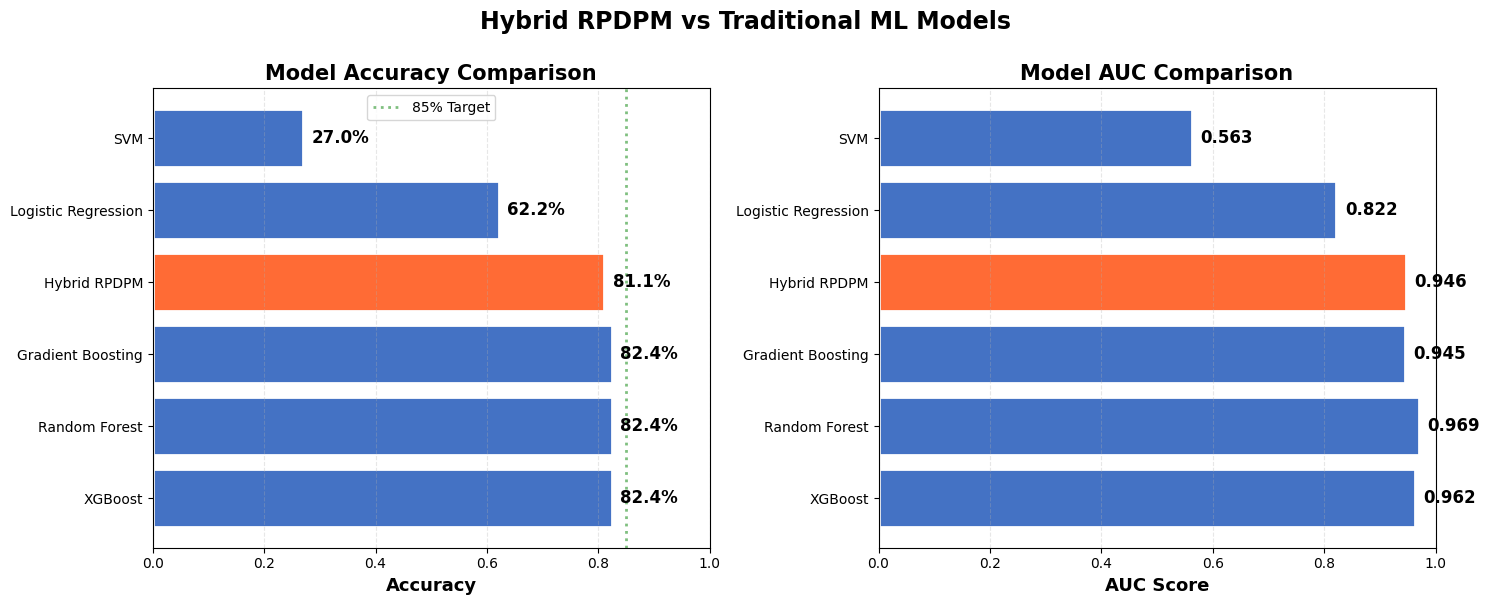

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

ax1 = axes[0]
model_names = [m.replace(' (Primary)', '') for m in comparison_df['Model']]
accs = comparison_df['Accuracy'].values
colors_bar = ['#FF6B35' if 'RPDPM' in m else '#4472C4' for m in comparison_df['Model']]

bars = ax1.barh(model_names, accs, color=colors_bar, edgecolor='white', linewidth=2)
ax1.set_xlabel('Accuracy', fontsize=13, fontweight='bold')
ax1.set_title('Model Accuracy Comparison', fontsize=15, fontweight='bold')
ax1.set_xlim(0, 1.0)
ax1.grid(axis='x', alpha=0.3, linestyle='--')
ax1.axvline(0.85, linestyle=':', color='green', linewidth=2, alpha=0.5, label='85% Target')
ax1.legend()

for bar, acc in zip(bars, accs):
    ax1.text(acc + 0.015, bar.get_y() + bar.get_height()/2,
             f'{acc:.1%}', va='center', fontsize=12, fontweight='bold')

ax2 = axes[1]
aucs = comparison_df['AUC'].values
bars2 = ax2.barh(model_names, aucs, color=colors_bar, edgecolor='white', linewidth=2)
ax2.set_xlabel('AUC Score', fontsize=13, fontweight='bold')
ax2.set_title('Model AUC Comparison', fontsize=15, fontweight='bold')
ax2.set_xlim(0, 1.0)
ax2.grid(axis='x', alpha=0.3, linestyle='--')

for bar, auc in zip(bars2, aucs):
    ax2.text(auc + 0.015, bar.get_y() + bar.get_height()/2,
             f'{auc:.3f}', va='center', fontsize=12, fontweight='bold')

plt.suptitle('Hybrid RPDPM vs Traditional ML Models', fontsize=17, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

## 8. Hybrid RPDPM Detailed Evaluation

HYBRID RPDPM - DETAILED EVALUATION

Classification Report:
              precision    recall  f1-score   support

 No Dementia       0.87      0.83      0.85        24
   Very Mild       0.79      0.60      0.68        25
    Dementia       0.78      1.00      0.88        25

    accuracy                           0.81        74
   macro avg       0.81      0.81      0.80        74
weighted avg       0.81      0.81      0.80        74



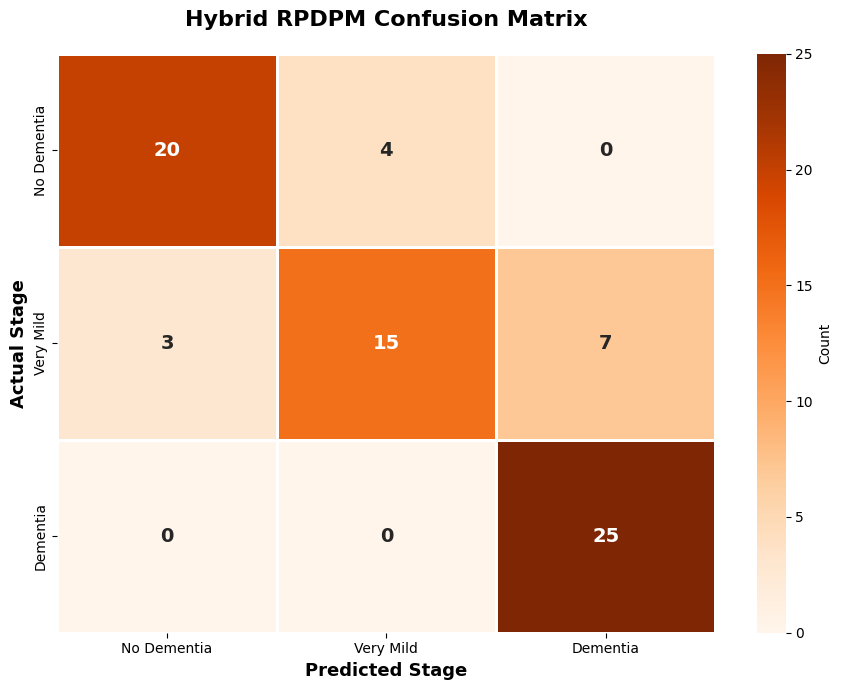

In [8]:
rpdpm_pred = results['Hybrid RPDPM (Primary)']['y_pred']

print('='*70)
print('HYBRID RPDPM - DETAILED EVALUATION')
print('='*70)
print('\nClassification Report:')
print(classification_report(y_test, rpdpm_pred,
      target_names=['No Dementia', 'Very Mild', 'Dementia']))

cm = confusion_matrix(y_test, rpdpm_pred)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['No Dementia', 'Very Mild', 'Dementia'],
            yticklabels=['No Dementia', 'Very Mild', 'Dementia'],
            cbar_kws={'label': 'Count'}, linewidths=2, linecolor='white',
            annot_kws={'fontsize': 14, 'fontweight': 'bold'})
plt.title('Hybrid RPDPM Confusion Matrix', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Predicted Stage', fontsize=13, fontweight='bold')
plt.ylabel('Actual Stage', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. New Patient Prediction

NEW PATIENT PREDICTION (HYBRID RPDPM)
Current Stage    : Very Mild
P(No Dementia)   : 5.9%
P(Very Mild)     : 89.0%
P(Dementia)      : 5.2%

5-Visit Progression Forecast:
 Visit  nWBV  MMSE     Stage Confidence
     1 0.736  25.0 Very Mild      90.6%
     2 0.728  23.0  Dementia      91.1%
     3 0.716  20.0  Dementia      97.8%
     4 0.700  16.0  Dementia      97.8%
     5 0.680  11.0  Dementia      98.2%


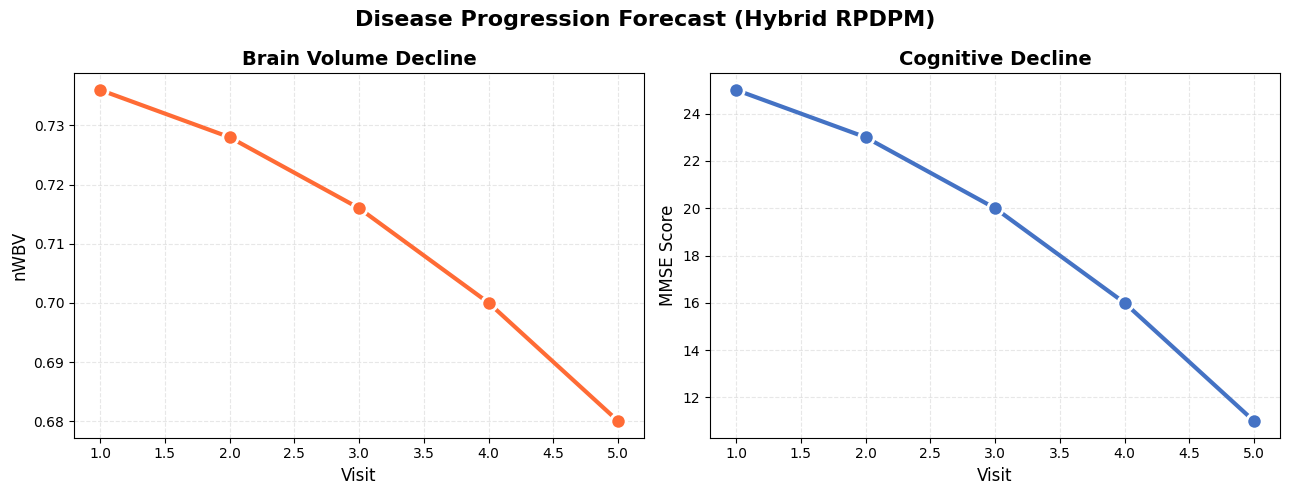

In [9]:
def simulate_progression(base_patient, visits=5):
    model = results['Hybrid RPDPM (Primary)']['model']
    records = []
    patient = base_patient.copy()
    
    for visit in range(1, visits + 1):
        patient['Visit'] = visit
        patient['nWBV'] = round(patient['nWBV'] - 0.004 * visit, 4)
        patient['MMSE'] = max(0, patient['MMSE'] - 1.0 * visit)
        
        input_df = pd.DataFrame([patient])[features]
        stage_pred = model.predict(input_df)[0]
        probs = model.predict_proba(input_df)[0]
        
        records.append({
            'Visit': visit, 'nWBV': patient['nWBV'], 'MMSE': round(patient['MMSE'], 1),
            'Stage': stage_labels[stage_pred], 'Confidence': f'{max(probs)*100:.1f}%'
        })
    
    return pd.DataFrame(records)

new_patient = {'Visit': 1, 'Age': 75, 'EDUC': 12, 'SES': 2, 'MMSE': 26,
               'eTIV': 1480, 'nWBV': 0.74, 'ASF': 1.15, 'M/F': 0}

hybrid_model = results['Hybrid RPDPM (Primary)']['model']
pred_df = pd.DataFrame([new_patient])[features]
prediction = hybrid_model.predict(pred_df)[0]
probs = hybrid_model.predict_proba(pred_df)[0]

print('='*70)
print('NEW PATIENT PREDICTION (HYBRID RPDPM)')
print('='*70)
print(f'Current Stage    : {stage_labels[prediction]}')
print(f'P(No Dementia)   : {probs[0]*100:.1f}%')
print(f'P(Very Mild)     : {probs[1]*100:.1f}%')
print(f'P(Dementia)      : {probs[2]*100:.1f}%')
print('\n5-Visit Progression Forecast:')
progression = simulate_progression(new_patient, visits=5)
print(progression.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(progression['Visit'], progression['nWBV'], marker='o',
             color='#FF6B35', linewidth=3, markersize=11, markeredgecolor='white', markeredgewidth=2)
axes[0].set_title('Brain Volume Decline', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Visit', fontsize=12)
axes[0].set_ylabel('nWBV', fontsize=12)
axes[0].grid(alpha=0.3, linestyle='--')

axes[1].plot(progression['Visit'], progression['MMSE'], marker='o',
             color='#4472C4', linewidth=3, markersize=11, markeredgecolor='white', markeredgewidth=2)
axes[1].set_title('Cognitive Decline', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Visit', fontsize=12)
axes[1].set_ylabel('MMSE Score', fontsize=12)
axes[1].grid(alpha=0.3, linestyle='--')

plt.suptitle('Disease Progression Forecast (Hybrid RPDPM)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()